In [2]:
import yfinance as yf
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
stocks = ["AMZN", "MSFT", "GOOG"]  # List of stock tickers
#start = dt.datetime.today() - dt.timedelta(360) # 30 days ago
#end = dt.datetime.today()

ohlcv_data = {}  # Dictionary to hold OHLCV data. Key-Value pair: Ticker-DataFrame

# get closing prices for each stock
for ticker in stocks:
    temp = yf.download(ticker, period="1y", interval="1d")
    temp.dropna(how="any", inplace=True) # type: ignore
    ohlcv_data[ticker] = temp


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [12]:
# rsi

# rsi = 100 - 100/(1+RS)
# RS = avg gain of n days UP / avg loss of n days
# search it up

# RMA is the exponentially weighted moving avg with alpha = 1/length
# RSI uses rma

def rsi(DF, n = 14):
    df = DF.copy()

    # change
    df["change"] = df["Close"] - df["Close"].shift(1)

    # gain and loss
    df["gain"] = np.where(df["change"] >= 0, df["change"], 0)
    df["loss"] = np.where(df["change"] < 0, -1*df["change"], 0)

    # avg gain and loss
    df["avgGain"] = df["gain"].ewm(alpha = 1/n, min_periods = n).mean()
    df["avgLoss"] = df["loss"].ewm(alpha = 1/n, min_periods = n).mean()

    # rs and rsi
    df["rs"] = df["avgGain"]/df["avgLoss"]
    df["rsi"] = 100 - (100/(1+df["rs"]))

    return df["rsi"]

for ticker in ohlcv_data:
    ohlcv_data[ticker]["RSI"] = rsi(ohlcv_data[ticker])

#print(ohlcv_data)

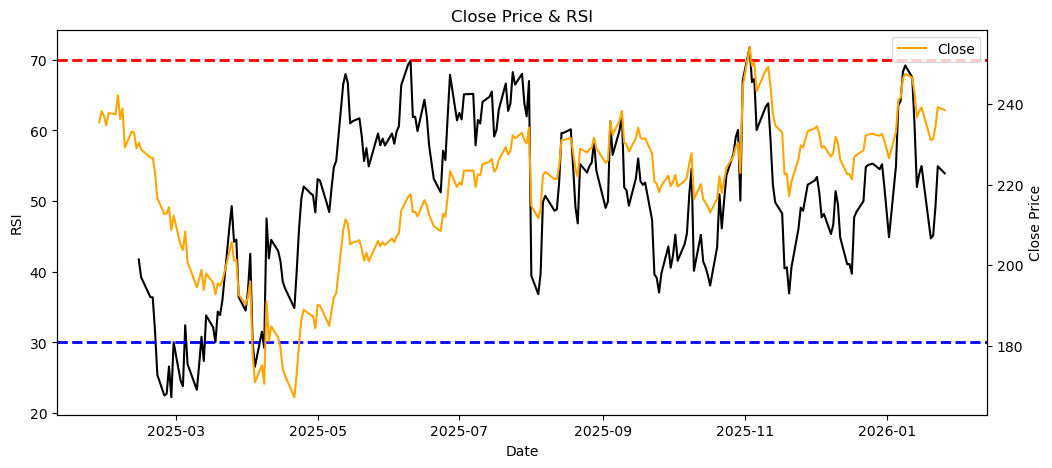

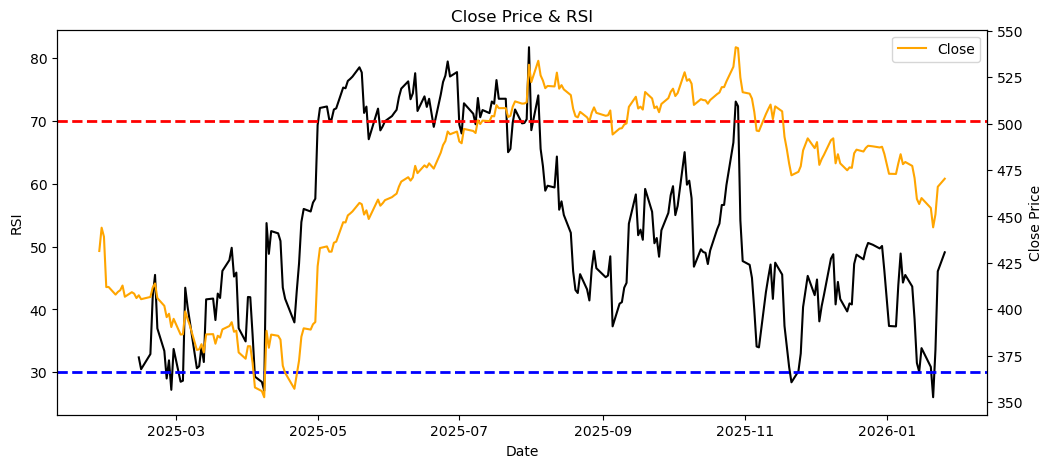

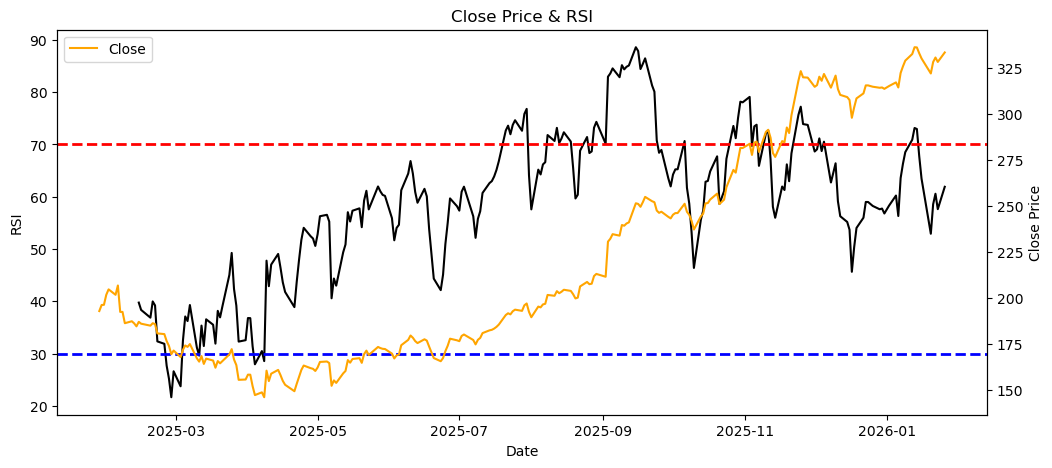

In [13]:
# graphing the rsi lines on each chart
for ticker in ohlcv_data:
    df = ohlcv_data[ticker].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(df.index, df["RSI"], label="RSI", color="black")
    plt.axhline(y=30, color="blue", linestyle="--", linewidth=2)
    plt.axhline(y=70, color="red", linestyle="--", linewidth=2)
    ax1.set_ylabel("RSI")
    
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["Close"], label="Close", color="orange")
    ax2.set_ylabel("Close Price")

    ax1.set_xlabel("Date")

    plt.title("Close Price & RSI")
    plt.legend()

    plt.show()

